In [1]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import statsmodels.api as sm

import concurrent.futures


import numpy as np
import pandas as pd
import polars as pl

import ast
import glob
import pickle
import dask
import os
import itertools

import pickle

#from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances, mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from statsmodels.regression.rolling import RollingOLS

from tqdm.notebook import tqdm

from multiprocessing import Pool, cpu_count
from joblib import Parallel, delayed
#from tqdm import tqdm
from collections import Counter
from functools import reduce

#client = Client(n_workers=20, memory_limit="10GB", interface='lo')
from concurrent.futures import ThreadPoolExecutor

from pprint import pprint
import os

pd.set_option('display.max_columns', None)

import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

In [2]:
augmented_df = pl.read_parquet("imputed_augmented_us-counties-states_latest_variants.parquet", low_memory=False).to_pandas()
augmented_df["date"] = pd.to_datetime(augmented_df["date"])
augmented_df["fips"] = augmented_df["fips"].astype(int)
augmented_df["days_from_start"] = augmented_df["days_from_start"].astype(int)
augmented_df["log_rolled_cases"] = np.log(augmented_df["rolled_cases"] + 1.1)
augmented_df = augmented_df.sort_values(by=["fips","date"])
augmented_df["shifted_log_rolled_cases"] = augmented_df.groupby("fips")["log_rolled_cases"].shift(-7)

/home/zwang937/.local/lib/python3.8/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [3]:
gt_columns = ["fips", "days_from_start", "shifted_log_rolled_cases"]
augmented_df_gt = augmented_df[gt_columns]
grouped = augmented_df_gt.groupby('fips')

for fips, group in grouped:
    missing_days = group['days_from_start'].diff().gt(1).sum()
    if missing_days > 0:
        print(f"Gap(s) found in 'days_from_start' for fips {fips}: {missing_days} gap(s)")


### Load TLGRF Benchmark Dataset

In [4]:
benchmark_TLGRF_dataset = pl.read_csv("../generate_benchmark_TLGRF_dataset/benchmark_TLGRF_dataset.csv", low_memory=False).to_pandas()
benchmark_TLGRF_dataset["date"] = pd.to_datetime(benchmark_TLGRF_dataset["date"])

df = benchmark_TLGRF_dataset.copy()
fips_list = df["fips"].unique()
display(benchmark_TLGRF_dataset)

,fips,days_from_start,intercept_TLGRF,r_TLGRF,county,state,date,rolled_cases,log_rolled_cases,shifted_log_rolled_cases,TLGRF_predicted_log_rolled_cases
0,1001,69,NaN,NaN,Autauga,Alabama,2020-03-30,5.142857,1.831438,2.469309,NaN
1,1001,70,NaN,NaN,Autauga,Alabama,2020-03-31,6.000000,1.960095,2.528012,NaN
2,1001,71,NaN,NaN,Autauga,Alabama,2020-04-01,6.857143,2.074070,2.550561,NaN
3,1001,72,NaN,NaN,Autauga,Alabama,2020-04-02,7.428571,2.143422,2.625703,NaN
4,1001,73,NaN,NaN,Autauga,Alabama,2020-04-03,8.285714,2.239189,2.676117,NaN
...,...,...,...,...,...,...,...,...,...,...,...
3390311,99999,1153,1456.032249,-0.030986,New York City,New York,2023-03-19,13972.285714,9.544910,NaN,9.328005
3390312,99999,1154,1389.214236,-0.039535,New York City,New York,2023-03-20,13317.571429,9.496922,NaN,9.220178
3390313,99999,1155,1323.021840,-0.054503,New York City,New York,2023-03-21,12458.714286,9.430264,NaN,9.048744
3390314,99999,1156,1531.624962,-0.024711,New York City,New York,2023-03-22,12154.857143,9.405575,NaN,9.232600


### Read in LLF CF Results

In [5]:
def read_csv_file(file_path):
    # Read the CSV file into a pandas DataFrame
    try:
        GRF_df = pd.read_csv(file_path)
        return GRF_df
    except pd.errors.EmptyDataError:
        print(file_path)

In [6]:
lambda_exponent = -2

directory = "./classical_causal_forest_results/llf_backtest_state_forests_windowsize=2_numtrees=200"

llf_cf_results_file_paths = [os.path.join(directory, file) for file in os.listdir(directory) if file.endswith("_lambda_exponent_{}.csv".format(lambda_exponent))]
with tqdm(total=len(llf_cf_results_file_paths), desc="Reading CSV files") as pbar:
    # Define the function for reading CSV files
    # Read the CSV files in parallel
    llf_cf_results_dfs = Parallel(n_jobs=-1)(delayed(read_csv_file)(file_path) for file_path in llf_cf_results_file_paths)
    pbar.update(len(llf_cf_results_file_paths))  # Manually update the progress bar
# Close the progress bar
pbar.close()

Reading CSV files:   0%|          | 0/1108 [00:00<?, ?it/s]

In [7]:
llf_cf_results = pd.concat(llf_cf_results_dfs).sort_values(by=["fips", "days_from_start"])
llf_cf_results["date"] = pd.to_datetime(llf_cf_results["date"])
llf_cf_results = llf_cf_results.rename(columns={"predicted_log_rolled_cases_LLF":"LLF_predicted_log_rolled_cases"})
llf_cf_results = llf_cf_results.dropna(subset=["LLF_predicted_log_rolled_cases"])
llf_cf_results = pd.merge(llf_cf_results, augmented_df_gt, on=["fips","days_from_start"], how="left")
#time_invariant_GRF_results = time_invariant_GRF_results.drop(columns=["predicted.grf.future", "predicted.grf.future.0", "Predicted_Double_Days"])
display(llf_cf_results)

,date,county,state,days_from_start,rolled_cases,fips,log_rolled_cases,r_LLF,var_r_LFF,LLF_predicted_log_rolled_cases,shifted_log_rolled_cases
0,2020-04-16,Autauga,Alabama,86,20.285714,1001,3.062723,0.010645,0.007556,3.137236,3.133629
1,2020-04-17,Autauga,Alabama,87,20.714286,1001,3.082565,0.021284,0.002479,3.231551,3.170286
2,2020-04-18,Autauga,Alabama,88,20.714286,1001,3.082565,0.023327,0.007432,3.245853,3.205646
3,2020-04-19,Autauga,Alabama,89,21.000000,1001,3.095578,0.002997,0.020266,3.116554,3.228543
4,2020-04-20,Autauga,Alabama,90,21.428571,1001,3.114784,0.034968,0.004238,3.359559,3.256447
...,...,...,...,...,...,...,...,...,...,...,...
2644291,2023-03-19,New York City,New York,1153,13972.285714,99999,9.544910,-0.037169,0.000975,9.284730,NaN
2644292,2023-03-20,New York City,New York,1154,13317.571429,99999,9.496922,-0.095464,0.002468,8.828672,NaN
2644293,2023-03-21,New York City,New York,1155,12458.714286,99999,9.430264,-0.042887,0.000677,9.130054,NaN
2644294,2023-03-22,New York City,New York,1156,12154.857143,99999,9.405575,-0.079802,0.006384,8.846958,NaN


### Read in LLF TLGRF Results

In [8]:
directory = "../../data/output/backtest_LLF_TLGRF_state_forests_windowsize=2"

LLF_TLGRF_results_file_paths = [os.path.join(directory, file) for file in os.listdir(directory) if file.endswith(".csv".format(lambda_exponent))]
with tqdm(total=len(LLF_TLGRF_results_file_paths), desc="Reading CSV files") as pbar:
    # Define the function for reading CSV files
    # Read the CSV files in parallel
    LLF_TLGRF_results_dfs = Parallel(n_jobs=-1)(delayed(read_csv_file)(file_path) for file_path in LLF_TLGRF_results_file_paths)
    pbar.update(len(LLF_TLGRF_results_file_paths))  # Manually update the progress bar
# Close the progress bar
pbar.close()

Reading CSV files:   0%|          | 0/1107 [00:00<?, ?it/s]

In [9]:
LLF_TLGRF_results = pd.concat(LLF_TLGRF_results_dfs).sort_values(by=["fips", "days_from_start"])
LLF_TLGRF_results["date"] = pd.to_datetime(LLF_TLGRF_results["datetime"])
LLF_TLGRF_results = LLF_TLGRF_results.rename(columns={"predicted.grf.future.0":"LLF_TLGRF_predicted_log_rolled_cases"})
LLF_TLGRF_results = LLF_TLGRF_results.dropna(subset=["LLF_TLGRF_predicted_log_rolled_cases"])
LLF_TLGRF_results = pd.merge(LLF_TLGRF_results, augmented_df_gt, on=["fips","days_from_start"], how="left")
#time_invariant_GRF_results = time_invariant_GRF_results.drop(columns=["predicted.grf.future", "predicted.grf.future.0", "Predicted_Double_Days"])
display(LLF_TLGRF_results)

,fips,county,state,days_from_start,datetime,log_rolled_cases.x,t0.hat,tau.hat,predicted.grf.future,LLF_TLGRF_predicted_log_rolled_cases,predicted.grf.future.last,Predicted_Double_Days,date,shifted_log_rolled_cases
0,1001,Autauga,Alabama,87,2020-04-17,3.030824,-30.223905,0.027201,3.379038,3.227526,3.221232,25.482239,2020-04-17,3.170286
1,1001,Autauga,Alabama,88,2020-04-18,3.030824,-313.663052,0.007754,3.168902,3.092858,3.085104,89.388589,2020-04-18,3.205646
2,1001,Autauga,Alabama,89,2020-04-19,3.044522,-53.913388,0.022203,3.328488,3.208446,3.199942,31.218995,2020-04-19,3.228543
3,1001,Autauga,Alabama,90,2020-04-20,3.064725,-56.107493,0.021719,3.325354,3.218275,3.216759,31.914203,2020-04-20,3.256447
4,1001,Autauga,Alabama,91,2020-04-21,3.064725,-195.866169,0.010912,3.206625,3.152020,3.141108,63.522388,2020-04-21,3.283593
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2636730,99999,New York City,New York,1153,2023-03-19,9.544831,1453.436030,-0.031250,9.169833,9.328144,9.326082,-22.180814,2023-03-19,NaN
2636731,99999,New York City,New York,1154,2023-03-20,9.496840,1396.500931,-0.038371,9.036389,9.237864,9.228243,-18.064386,2023-03-20,NaN
2636732,99999,New York City,New York,1155,2023-03-21,9.430176,1335.038415,-0.050963,8.818616,9.089133,9.073432,-13.600898,2023-03-21,NaN
2636733,99999,New York City,New York,1156,2023-03-22,9.405484,1524.074711,-0.025211,9.102955,9.228490,9.229009,-27.494139,2023-03-22,NaN


In [10]:
LLF_TLGRF_results.columns

Index(['fips', 'county', 'state', 'days_from_start', 'datetime',
       'log_rolled_cases.x', 't0.hat', 'tau.hat', 'predicted.grf.future',
       'LLF_TLGRF_predicted_log_rolled_cases', 'predicted.grf.future.last',
       'Predicted_Double_Days', 'date', 'shifted_log_rolled_cases'],
      dtype='object')

### Read TLGRF Top 10 Results

In [11]:
directory = "../../data/output/backtest_TLGRF_Top10_state_forests_windowsize=2"

TLGRF_Top10_results_file_paths = [os.path.join(directory, file) for file in os.listdir(directory) if file.endswith(".csv".format(lambda_exponent))]
with tqdm(total=len(TLGRF_Top10_results_file_paths), desc="Reading CSV files") as pbar:
    # Define the function for reading CSV files
    # Read the CSV files in parallel
    TLGRF_Top10_results_dfs = Parallel(n_jobs=-1)(delayed(read_csv_file)(file_path) for file_path in TLGRF_Top10_results_file_paths)
    pbar.update(len(TLGRF_Top10_results_file_paths))  # Manually update the progress bar
# Close the progress bar
pbar.close()

Reading CSV files:   0%|          | 0/1107 [00:00<?, ?it/s]

In [12]:
TLGRF_Top10_results = pd.concat(TLGRF_Top10_results_dfs).sort_values(by=["fips", "days_from_start"])
TLGRF_Top10_results["date"] = pd.to_datetime(TLGRF_Top10_results["datetime"])
TLGRF_Top10_results = TLGRF_Top10_results.rename(columns={"predicted.grf.future.0":"LLF_TLGRF_predicted_log_rolled_cases"})
TLGRF_Top10_results = TLGRF_Top10_results.dropna(subset=["LLF_TLGRF_predicted_log_rolled_cases"])
TLGRF_Top10_results = pd.merge(TLGRF_Top10_results, augmented_df_gt, on=["fips","days_from_start"], how="left")
#time_invariant_GRF_results = time_invariant_GRF_results.drop(columns=["predicted.grf.future", "predicted.grf.future.0", "Predicted_Double_Days"])
display(TLGRF_Top10_results)

,fips,county,state,days_from_start,datetime,log_rolled_cases.x,t0.hat,tau.hat,predicted.grf.future,LLF_TLGRF_predicted_log_rolled_cases,predicted.grf.future.last,Predicted_Double_Days,date,shifted_log_rolled_cases
0,1001,Autauga,Alabama,87,2020-04-17,3.030824,22.806762,0.051570,3.671469,3.422481,3.391817,13.440775,2020-04-17,3.170286
1,1001,Autauga,Alabama,88,2020-04-18,3.030824,6.302735,0.040104,3.557095,3.351654,3.311550,17.283839,2020-04-18,3.205646
2,1001,Autauga,Alabama,89,2020-04-19,3.044522,-0.003699,0.036451,3.499472,3.322435,3.299682,19.015638,2020-04-19,3.228543
3,1001,Autauga,Alabama,90,2020-04-20,3.064725,-2.872816,0.034877,3.483247,3.323537,3.308863,19.874146,2020-04-20,3.256447
4,1001,Autauga,Alabama,91,2020-04-21,3.064725,-9.029015,0.032366,3.464072,3.323651,3.291285,21.416085,2020-04-21,3.283593
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2636730,99999,New York City,New York,1153,2023-03-19,9.544831,1542.232551,-0.024211,9.254297,9.384454,9.375353,-28.629232,2023-03-19,NaN
2636731,99999,New York City,New York,1154,2023-03-20,9.496840,1514.086156,-0.026013,9.184688,9.336730,9.314751,-26.646595,2023-03-20,NaN
2636732,99999,New York City,New York,1155,2023-03-21,9.430176,1517.022768,-0.025694,9.121851,9.291290,9.250320,-26.977313,2023-03-21,NaN
2636733,99999,New York City,New York,1156,2023-03-22,9.405484,1570.554423,-0.022418,9.136471,9.250833,9.248560,-30.919510,2023-03-22,NaN


### Load LL Regression Forest Blocked

In [13]:
directory = "./ll_regression_forest_blocked/llf_backtest_state_forests_windowsize=2_numtrees=200"

LL_Regression_Blocked_results_file_paths = [os.path.join(directory, file) for file in os.listdir(directory) if file.endswith(".csv")]
with tqdm(total=len(LL_Regression_Blocked_results_file_paths), desc="Reading CSV files") as pbar:
    # Define the function for reading CSV files
    # Read the CSV files in parallel
    LL_Regression_Blocked_results_dfs = Parallel(n_jobs=-1)(delayed(read_csv_file)(file_path) for file_path in LL_Regression_Blocked_results_file_paths)
    pbar.update(len(LL_Regression_Blocked_results_file_paths))  # Manually update the progress bar
# Close the progress bar
pbar.close()

Reading CSV files:   0%|          | 0/1107 [00:00<?, ?it/s]

In [14]:
LL_Regression_Blocked_results = pd.concat(LL_Regression_Blocked_results_dfs).sort_values(by=["fips", "days_from_start"])
LL_Regression_Blocked_results["date"] = pd.to_datetime(LL_Regression_Blocked_results["date"])
LL_Regression_Blocked_results = LL_Regression_Blocked_results.rename(columns={"predicted_log_rolled_cases_LLF":"LLF_predicted_log_rolled_cases"})
LL_Regression_Blocked_results = LL_Regression_Blocked_results.dropna(subset=["LLF_predicted_log_rolled_cases"])
LL_Regression_Blocked_results = pd.merge(LL_Regression_Blocked_results, augmented_df_gt, on=["fips","days_from_start"], how="left")
#time_invariant_GRF_results = time_invariant_GRF_results.drop(columns=["predicted.grf.future", "predicted.grf.future.0", "Predicted_Double_Days"])
display(LL_Regression_Blocked_results)

,date,county,state,days_from_start,rolled_cases,fips,log_rolled_cases,r_LLF,var_r_LFF,LLF_predicted_log_rolled_cases,shifted_log_rolled_cases
0,2020-04-17,Autauga,Alabama,87,20.714286,1001,3.030824,2.090668e-02,0.000000,3.177170,3.170286
1,2020-04-18,Autauga,Alabama,88,20.714286,1001,3.030824,-4.186207e-15,0.000000,3.030824,3.205646
2,2020-04-19,Autauga,Alabama,89,21.000000,1001,3.044522,1.369884e-02,0.000000,3.140414,3.228543
3,2020-04-20,Autauga,Alabama,90,21.428571,1001,3.064725,2.020271e-02,0.000000,3.206144,3.256447
4,2020-04-21,Autauga,Alabama,91,21.428571,1001,3.064725,-9.015990e-15,0.000000,3.064725,3.283593
...,...,...,...,...,...,...,...,...,...,...,...
2640623,2023-03-19,New York City,New York,1153,13972.285714,99999,9.544831,-3.446605e-02,0.000006,9.303569,NaN
2640624,2023-03-20,New York City,New York,1154,13317.571429,99999,9.496840,-3.857645e-02,0.000032,9.226804,NaN
2640625,2023-03-21,New York City,New York,1155,12458.714286,99999,9.430176,-6.666400e-02,0.000000,8.963528,NaN
2640626,2023-03-22,New York City,New York,1156,12154.857143,99999,9.405484,-2.469147e-02,0.000000,9.232644,NaN


### Load LL Regression Forest Blocked Top 10

In [15]:
directory = "./ll_regression_forest_blocked_Top10/llf_backtest_state_forests_windowsize=2_numtrees=200"

LL_Regression_Blocked_Top10_results_file_paths = [os.path.join(directory, file) for file in os.listdir(directory) if file.endswith(".csv")]
with tqdm(total=len(LL_Regression_Blocked_Top10_results_file_paths), desc="Reading CSV files") as pbar:
    # Define the function for reading CSV files
    # Read the CSV files in parallel
    LL_Regression_Blocked_results_Top10_dfs = Parallel(n_jobs=-1)(delayed(read_csv_file)(file_path) for file_path in LL_Regression_Blocked_Top10_results_file_paths)
    pbar.update(len(LL_Regression_Blocked_Top10_results_file_paths))  # Manually update the progress bar
# Close the progress bar
pbar.close()

Reading CSV files:   0%|          | 0/1109 [00:00<?, ?it/s]

In [16]:
LL_Regression_Blocked_Top10_results = pd.concat(LL_Regression_Blocked_results_Top10_dfs).sort_values(by=["fips", "days_from_start"])
LL_Regression_Blocked_Top10_results["date"] = pd.to_datetime(LL_Regression_Blocked_results["date"])
LL_Regression_Blocked_Top10_results = LL_Regression_Blocked_Top10_results.rename(columns={"predicted_log_rolled_cases_LLF":"LLF_predicted_log_rolled_cases"})
LL_Regression_Blocked_Top10_results = LL_Regression_Blocked_Top10_results.dropna(subset=["LLF_predicted_log_rolled_cases"])
LL_Regression_Blocked_Top10_results = pd.merge(LL_Regression_Blocked_Top10_results, augmented_df_gt, on=["fips","days_from_start"], how="left")
#time_invariant_GRF_results = time_invariant_GRF_results.drop(columns=["predicted.grf.future", "predicted.grf.future.0", "Predicted_Double_Days"])
display(LL_Regression_Blocked_Top10_results)

,date,county,state,days_from_start,rolled_cases,fips,log_rolled_cases,r_LLF,var_r_LFF,LLF_predicted_log_rolled_cases,shifted_log_rolled_cases
0,2020-04-17,Autauga,Alabama,87,20.714286,1001,3.030824,0.016831,0.000097,3.148639,3.170286
1,2020-04-17,Autauga,Alabama,88,20.714286,1001,3.030824,0.008767,0.000044,3.092190,3.205646
2,2020-04-17,Autauga,Alabama,89,21.000000,1001,3.044522,0.004362,0.000146,3.075057,3.228543
3,2020-04-17,Autauga,Alabama,90,21.428571,1001,3.064725,-0.005386,0.000029,3.027023,3.256447
4,2020-04-17,Autauga,Alabama,91,21.428571,1001,3.064725,-0.008687,0.000100,3.003917,3.283593
...,...,...,...,...,...,...,...,...,...,...,...
2646423,2020-07-11,New York City,New York,1153,13972.285714,99999,9.544831,-0.018030,0.000044,9.418620,NaN
2646424,2020-07-02,New York City,New York,1154,13317.571429,99999,9.496840,-0.019403,0.000199,9.361016,NaN
2646425,2020-06-16,New York City,New York,1155,12458.714286,99999,9.430176,-0.021200,0.000207,9.281778,NaN
2646426,2020-06-05,New York City,New York,1156,12154.857143,99999,9.405484,-0.020416,0.000028,9.262571,NaN


### Metrics

In [17]:
rmse_LLF_func = lambda x: np.sqrt(np.nanmean((x["LLF_predicted_log_rolled_cases"] - x["shifted_log_rolled_cases"]) ** 2))
mae_LLF_func = lambda x: np.nanmean(np.abs(x["LLF_predicted_log_rolled_cases"] - x["shifted_log_rolled_cases"]))

rmse_TLGRF_func = lambda x: np.sqrt(np.nanmean((x["TLGRF_predicted_log_rolled_cases"] - x["shifted_log_rolled_cases"]) ** 2))
mae_TLGRF_func = lambda x: np.nanmean(np.abs(x["TLGRF_predicted_log_rolled_cases"] - x["shifted_log_rolled_cases"]))

rmse_LLF_TLGRF_func = lambda x: np.sqrt(np.nanmean((x["LLF_TLGRF_predicted_log_rolled_cases"] - x["shifted_log_rolled_cases"]) ** 2))
mae_LLF_TLGRF_func = lambda x: np.nanmean(np.abs(x["LLF_TLGRF_predicted_log_rolled_cases"] - x["shifted_log_rolled_cases"]))

log_20 = np.log(20 + 1.1)

TLGRF_df = benchmark_TLGRF_dataset[benchmark_TLGRF_dataset["log_rolled_cases"] >= log_20]
TLGRF_df = TLGRF_df[TLGRF_df["date"] <= "2022-12-31"]

LLF_CF_df = llf_cf_results[llf_cf_results["log_rolled_cases"] >= log_20]
LLF_CF_df = LLF_CF_df[LLF_CF_df["date"] <= "2022-12-31"]

LL_Regression_Blocked_df = LL_Regression_Blocked_results[LL_Regression_Blocked_results["log_rolled_cases"] >= log_20]
LL_Regression_Blocked_df = LL_Regression_Blocked_df[LL_Regression_Blocked_df["date"] <= "2022-12-31"]

LL_Regression_Blocked_Top10_df = LL_Regression_Blocked_Top10_results[LL_Regression_Blocked_Top10_results["log_rolled_cases"] >= log_20]
LL_Regression_Blocked_Top10_df = LL_Regression_Blocked_Top10_df[LL_Regression_Blocked_Top10_df["date"] <= "2022-12-31"]


LLF_TLGRF_df = LLF_TLGRF_results[LLF_TLGRF_results["log_rolled_cases.x"] >= log_20]
LLF_TLGRF_df = LLF_TLGRF_df[LLF_TLGRF_df["date"] <= "2022-12-31"]

TLGRF_Top10_df = TLGRF_Top10_results[TLGRF_Top10_results["log_rolled_cases.x"] >= log_20]
TLGRF_Top10_df = TLGRF_Top10_df[TLGRF_Top10_df["date"] <= "2022-12-31"]


#TLGRF
RMSE_TLGRF = TLGRF_df.groupby("date").apply(rmse_TLGRF_func)
MAE_TLGRF = TLGRF_df.groupby("date").apply(mae_TLGRF_func)
#LLF CF
RMSE_LLF_CF_df = LLF_CF_df.groupby("date").apply(rmse_LLF_func)
MAE_LLF_CF_df = LLF_CF_df.groupby("date").apply(mae_LLF_func)
#LL Regression Blocked
RMSE_LL_Regression_Blocked_df = LL_Regression_Blocked_df.groupby("date").apply(rmse_LLF_func)
MAE_LL_Regression_Blocked_df = LL_Regression_Blocked_df.groupby("date").apply(mae_LLF_func)

#LL Regression Blocked Top 10
RMSE_LL_Regression_Blocked_Top10_df = LL_Regression_Blocked_Top10_df.groupby("date").apply(rmse_LLF_func)
MAE_LL_Regression_Blocked_Top10_df = LL_Regression_Blocked_Top10_df.groupby("date").apply(mae_LLF_func)

#LLF TLGRF
RMSE_LLF_TLGRF_df = LLF_TLGRF_df.groupby("date").apply(rmse_LLF_TLGRF_func)
MAE_LLF_TLGRF_df = LLF_TLGRF_df.groupby("date").apply(mae_LLF_TLGRF_func)

# TLGRF Top10
RMSE_TLGRF_Top10_df = TLGRF_Top10_df.groupby("date").apply(rmse_LLF_TLGRF_func)
MAE_TLGRF_Top10_df = TLGRF_Top10_df.groupby("date").apply(mae_LLF_TLGRF_func)



/tmp/ipykernel_1167133/2765202688.py:4: RuntimeWarning: Mean of empty slice
  rmse_TLGRF_func = lambda x: np.sqrt(np.nanmean((x["TLGRF_predicted_log_rolled_cases"] - x["shifted_log_rolled_cases"]) ** 2))
/tmp/ipykernel_1167133/2765202688.py:5: RuntimeWarning: Mean of empty slice
  mae_TLGRF_func = lambda x: np.nanmean(np.abs(x["TLGRF_predicted_log_rolled_cases"] - x["shifted_log_rolled_cases"]))


In [18]:
combined_daily_metrics_df = pd.DataFrame()
combined_daily_metrics_df["MAE TLGRF"] = MAE_TLGRF
combined_daily_metrics_df["RMSE TLGRF"] = RMSE_TLGRF

combined_daily_metrics_df["MAE LLF CF"] = MAE_LLF_CF_df
combined_daily_metrics_df["RMSE LLF CF"] = RMSE_LLF_CF_df

combined_daily_metrics_df["MAE LLF TLGRF"] = MAE_LLF_TLGRF_df
combined_daily_metrics_df["RMSE LLF TLGRFF"] = RMSE_LLF_TLGRF_df

combined_daily_metrics_df["MAE TLGRF Top 10"] = MAE_TLGRF_Top10_df
combined_daily_metrics_df["RMSE TLGRF Top 10"] = RMSE_TLGRF_Top10_df

combined_daily_metrics_df["MAE LL Regression Blocked"] = MAE_LL_Regression_Blocked_df
combined_daily_metrics_df["RMSE LL Regression Blocked"] = RMSE_LL_Regression_Blocked_df

combined_daily_metrics_df["MAE LL Regression Blocked Top 10"] = MAE_LL_Regression_Blocked_Top10_df
combined_daily_metrics_df["RMSE LL Regression Blocked Top 10"] = RMSE_LL_Regression_Blocked_Top10_df


combined_daily_metrics_df = combined_daily_metrics_df.dropna(subset=['MAE TLGRF'])



combined_daily_metrics_df.to_csv("combined_LLF_daily_metrics.csv" ,index=True)

In [19]:
combined_daily_metrics_df

,MAE TLGRF,RMSE TLGRF,MAE LLF CF,RMSE LLF CF,MAE LLF TLGRF,RMSE LLF TLGRFF,MAE TLGRF Top 10,RMSE TLGRF Top 10,MAE LL Regression Blocked,RMSE LL Regression Blocked,MAE LL Regression Blocked Top 10,RMSE LL Regression Blocked Top 10
date,,,,,,,,,,,,
2020-03-12,0.693988,0.770719,1.160561,1.605439,0.889292,0.914777,0.798331,0.887993,0.730555,0.782658,NaN,NaN
2020-03-13,0.851022,0.879799,1.259766,1.567460,0.858349,0.908215,0.871113,0.929174,0.418667,0.566858,NaN,NaN
2020-03-14,0.673650,0.769575,1.066003,1.224620,0.592780,0.654088,0.733169,0.849658,0.714161,0.787454,NaN,NaN
2020-03-15,0.686867,0.784427,1.283929,1.469863,0.745142,0.835763,0.749605,0.857142,0.456305,0.556963,NaN,NaN
2020-03-16,0.738701,0.830998,0.669056,0.845322,0.502231,0.619621,0.802866,0.890531,0.453078,0.556981,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
2022-12-27,0.199477,0.263357,0.197659,0.258959,0.194185,0.259056,0.202495,0.266065,0.201635,0.320986,0.143743,0.213009
2022-12-28,0.130100,0.181111,0.224020,0.286971,0.126309,0.175956,0.153429,0.209431,0.124662,0.175381,0.138493,0.196786
2022-12-29,0.112732,0.174124,0.232400,0.323627,0.111964,0.173235,0.155262,0.217831,0.111760,0.173488,0.145564,0.213953


In [20]:
combined_daily_metrics_df.columns

Index(['MAE TLGRF', 'RMSE TLGRF', 'MAE LLF CF', 'RMSE LLF CF', 'MAE LLF TLGRF',
       'RMSE LLF TLGRFF', 'MAE TLGRF Top 10', 'RMSE TLGRF Top 10',
       'MAE LL Regression Blocked', 'RMSE LL Regression Blocked',
       'MAE LL Regression Blocked Top 10',
       'RMSE LL Regression Blocked Top 10'],
      dtype='object')

In [21]:
## Now train a new TLGRF, don't call local linearity when predicting, use the Top 10 most important features
### aka TLGRF Top 10 Only

In [22]:
metrics_comparison_df = pd.DataFrame()

metrics_comparison_df["MAE"] = [MAE_LLF_CF_df.median(), MAE_LL_Regression_Blocked_df.median(),MAE_LL_Regression_Blocked_Top10_df.median(), MAE_LLF_TLGRF_df.median(), MAE_TLGRF_Top10_df.median(), MAE_TLGRF.median()]
metrics_comparison_df["RMSE"] = [RMSE_LLF_CF_df.median(), RMSE_LL_Regression_Blocked_df.median(), RMSE_LL_Regression_Blocked_Top10_df.median(), RMSE_LLF_TLGRF_df.median(), RMSE_TLGRF_Top10_df.median(), RMSE_TLGRF.median()]
metrics_comparison_df.index = ["LLF CF", "LL Regression Blocked", "LL Regression Blocked Top10", "LLF TLGRF", "TLGRF Top10", "TLGRF"]
metrics_comparison_df

,MAE,RMSE
LLF CF,0.282298,0.383302
LL Regression Blocked,0.134853,0.220483
LL Regression Blocked Top10,0.152257,0.231613
LLF TLGRF,0.125501,0.194550
TLGRF Top10,0.176690,0.253957
TLGRF,0.126516,0.194870


### Describe the experiments in three dimensions:
 * During training time, did we use all features or top 10
 * During prediction time, do we correct for the bias via local linearity on all features / on top 10 / not at all?
 * Underlying forest: Causal Forest (with or without blocking) / Regression Forest (blocking only)

### Comments:
 * `LLF CF LL on Top 10`: Running ll_predict with local linear on the Top 10 most important features on a classical time variant causal forest (Classical GRF)
 * `LL Regression Blocked, calling ll predict on all features`: Trained ll_regression_forest on all features, with blocking structure
 * `LL Regression Blocked trained only on Top 10 features`: Trained ll_regression_forest on the Top 10 most important features only, with blocking structure, and calling local linearity on all of them
 * `LL TLGRF`: Trained TLGRF on all features, then calling predict with local linearity on the Top 10 most important features
 * `TLGRF trained only on Top 10 features without calling LL`: Trained TLGRF on Top 10 most important features only. No local lienarity
 * `TLGRF`: TLGRF as usual

In [23]:
# Run one more: Blocked structure on Regression Forest without local linearity

In [24]:
#Classical GRF without time varying features 0.218 0.291
#Classical GRF with time varying features 0.204 0.275
#TLGRF 0.127 0.195

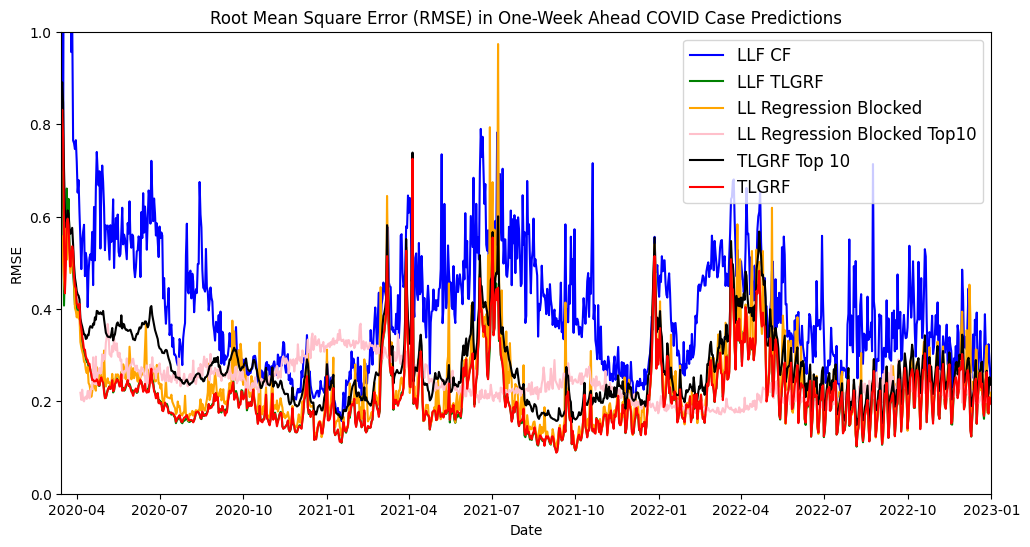

In [25]:
plt.figure(figsize=(12,6))

plt.plot(RMSE_LLF_CF_df, label="LLF CF", color="blue")
plt.plot(RMSE_LLF_TLGRF_df, label="LLF TLGRF", color="green")
plt.plot(RMSE_LL_Regression_Blocked_df, label="LL Regression Blocked", color="orange")

plt.plot(RMSE_LL_Regression_Blocked_Top10_df, label="LL Regression Blocked Top10", color="pink")

plt.plot(RMSE_TLGRF_Top10_df, label="TLGRF Top 10", color="black")
plt.plot(RMSE_TLGRF, label="TLGRF", color="red")



plt.legend(loc='upper right', fontsize='large')  # Adjust the bbox_to_anchor to increase the size
plt.xlabel("Date")
plt.ylabel("RMSE")
plt.title("Root Mean Square Error (RMSE) in One-Week Ahead COVID Case Predictions")
plt.xlim(pd.to_datetime('2020-03-15'), pd.to_datetime('2023-01-01'))
plt.ylim(0,1.0)
plt.savefig("LLF_TLGRF_rmse.png")
plt.show()


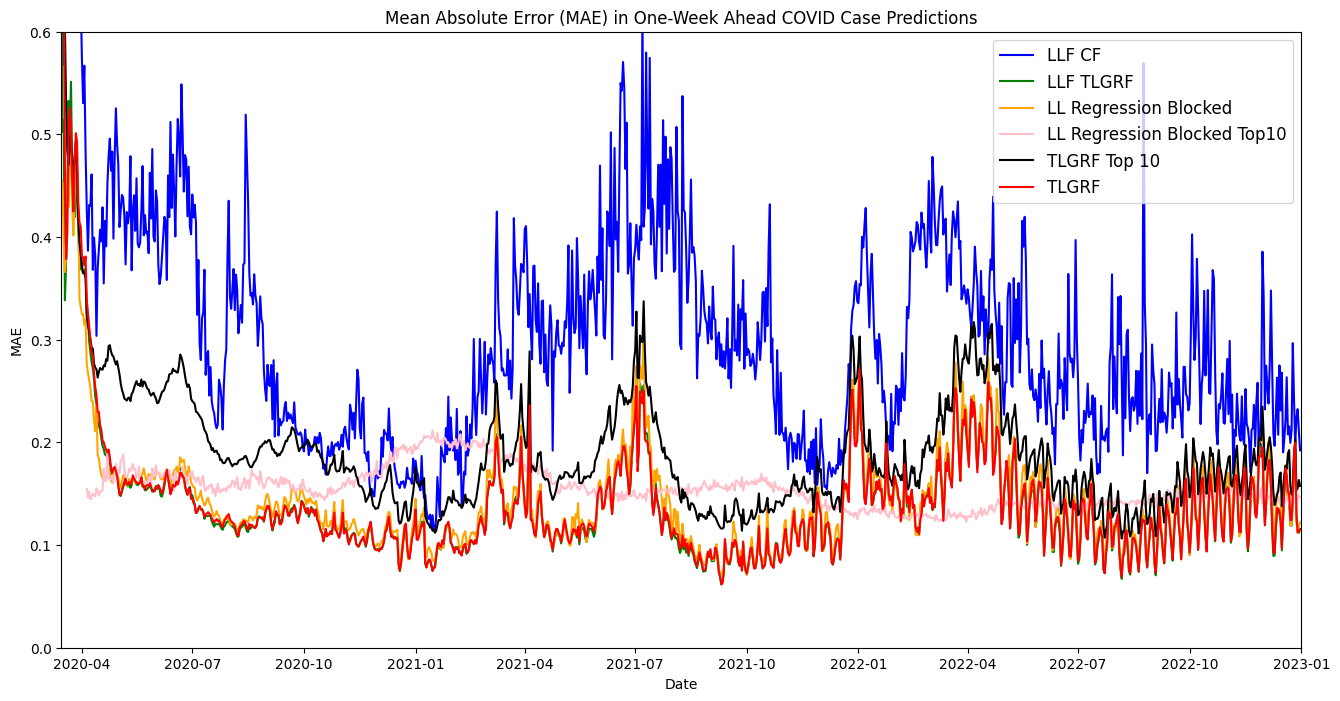

In [26]:
plt.figure(figsize=(16,8))

plt.plot(MAE_LLF_CF_df, label="LLF CF", color="blue")
plt.plot(MAE_LLF_TLGRF_df, label="LLF TLGRF", color="green")
plt.plot(MAE_LL_Regression_Blocked_df, label="LL Regression Blocked", color="orange")

plt.plot(MAE_LL_Regression_Blocked_Top10_df, label="LL Regression Blocked Top10", color="pink")

plt.plot(MAE_TLGRF_Top10_df, label="TLGRF Top 10", color="black")

plt.plot(MAE_TLGRF, label="TLGRF", color="red")

plt.legend(loc='upper right', fontsize='large')  # Adjust the bbox_to_anchor to increase the size
plt.xlabel("Date")
plt.ylabel("MAE")
plt.title("Mean Absolute Error (MAE) in One-Week Ahead COVID Case Predictions")
plt.xlim(pd.to_datetime('2020-03-15'), pd.to_datetime('2023-01-01'))
plt.ylim(0,0.6)
plt.savefig("LLF_TLGRF_mae.png")

plt.show()

In [27]:
RMSE_TLGRF.to_csv("RMSE_TLGRF.csv")
MAE_TLGRF.to_csv("MAE_TLGRF.csv")

RMSE_LLF_CF_df.to_csv("RMSE_LLF_CF_df.csv")
MAE_LLF_CF_df.to_csv("MAE_LLF_CF_df.csv")

RMSE_LLF_TLGRF_df.to_csv("RMSE_LLF_TLGRF_df.csv")
MAE_LLF_TLGRF_df.to_csv("MAE_LLF_TLGRF_df.csv")

RMSE_TLGRF_Top10_df.to_csv("RMSE_TLGRF_Top10_df.csv")
MAE_TLGRF_Top10_df.to_csv("MAE_TLGRF_Top10_df.csv")


RMSE_LL_Regression_Blocked_df.to_csv("RMSE_LL_Regression_Blocked_df.csv")
MAE_LL_Regression_Blocked_df.to_csv("MAE_LL_Regression_Blocked_df.csv")

RMSE_LL_Regression_Blocked_Top10_df.to_csv("RMSE_LL_Regression_Blocked_Top10_df.csv")
MAE_LL_Regression_Blocked_Top10_df.to_csv("MAE_LL_Regression_Blocked_Top10_df")

In [28]:
break

SyntaxError: 'break' outside loop (668683560.py, line 1)

### Compare `r` estimates

In [ ]:
r_TLGRF_df = benchmark_TLGRF_dataset[["fips","days_from_start","date", "state","county","r_TLGRF"]]
r_LLF_df = llf_results[["fips","days_from_start","date", "state","county","r_LLF"]]
r_comparison_df = pd.merge(r_TLGRF_df, r_LLF_df[["fips","days_from_start","r_LLF"]], on=["fips","days_from_start"], how="inner")
r_comparison_df = r_comparison_df[r_comparison_df["date"] <= "2022-12-31"]
r_comparison_df["difference"] = r_comparison_df["r_TLGRF"] - r_comparison_df["r_LLF"]

display(r_comparison_df)

In [ ]:
grouped = r_comparison_df.groupby('date')

# Compute daily differences
daily_diff = grouped["difference"].mean().reset_index(name='difference')

In [ ]:
display(daily_diff)

In [ ]:
plt.figure(figsize=(16,8))

# Plot the differences
plt.figure(figsize=(10, 6))
plt.plot(daily_diff['date'], daily_diff['difference'])
plt.xlabel('Date')
plt.ylabel('Difference')
plt.xlim(pd.to_datetime('2020-03-15'), pd.to_datetime('2023-01-01'))

plt.title('Daily Difference between r_TLGRF and r_LLF')
plt.grid(True)

plt.savefig("r_TLGRF vs r_LLF.png")

plt.show()
